In [34]:
import numpy as np
import pandas as pd

df = pd.read_csv('./dataset/extended_data.csv')

# print(df.head())
# print(df.info())
# print(df.describe())
# print()
# print(df.isnull().sum()) // in column miles_per_gallon -> 17 NULL and msrp -> 17 NULL
# print(df['brand'].value_counts())

# anomali = df[df['miles_per_gallon'] == -1.0]
# print(anomali)

df = df.drop(index=26330)
df = df.reset_index(drop=True)
print(df.describe())

         model_year  miles_per_gallon  premium_version          msrp  \
count  28142.000000      28125.000000     28142.000000  2.812500e+04   
mean    2013.456791         21.770052         0.533544  5.736739e+04   
std        6.847657         13.471733         0.498882  6.146341e+04   
min     1974.000000          0.000000         0.000000  0.000000e+00   
25%     2009.000000         17.000000         0.000000  3.000000e+04   
50%     2015.000000         20.000000         1.000000  4.120000e+04   
75%     2019.000000         24.000000         1.000000  6.400000e+04   
max     2024.000000        234.000000         1.000000  2.500000e+06   

       collection_car  
count    28142.000000  
mean         0.137304  
std          0.344174  
min          0.000000  
25%          0.000000  
50%          0.000000  
75%          0.000000  
max          1.000000  


In [ ]:
df['miles_per_gallon'] = df['miles_per_gallon'].fillna(df['miles_per_gallon'].mean())
df['msrp'] = df['msrp'].fillna(df['msrp'].mean())

#print(df.isnull().sum()) // yeay, there's no NULL anymore!
# print(f"Ukuran dataset bersih sekarang: {df.shape}")
# print((df['model_year'] < 2000).sum())

anomali = df[df['msrp'] > (24 * 1000000.0)]
print(anomali)

Empty DataFrame
Columns: [model_year, brand, model, type, miles_per_gallon, premium_version, msrp, collection_car]
Index: []


jumlah brand unik ada: <ArrowStringArray>
[       'Toyota',           'RAM',          'Ford',           'BMW',
 'Mercedes-Benz',         'Lexus',     'Chevrolet',          'Audi',
       'Porsche',       'Genesis',        'Hummer',         'Mazda',
          'Land',         'Honda',          'Jeep',        'Jaguar',
       'Lincoln',        'Nissan',        'Saturn',      'Cadillac',
           'Kia',      'Maserati',    'Volkswagen',         'Dodge',
        'Subaru',      'Chrysler',       'Hyundai',    'Mitsubishi',
      'INFINITI',         'Tesla',   'Lamborghini',           'GMC',
          'MINI',         'Acura',         'Buick',        'Rivian',
       'Pontiac',          'Alfa',       'Mercury',         'Volvo',
   'Rolls-Royce',       'McLaren',       'Bentley',         'Aston',
          'FIAT',         'Scion',       'Ferrari',         'Lucid',
          'Saab',       'Maybach',         'Karma',        'Suzuki',
         'Lotus',       'Bugatti',      'Plymouth',         '

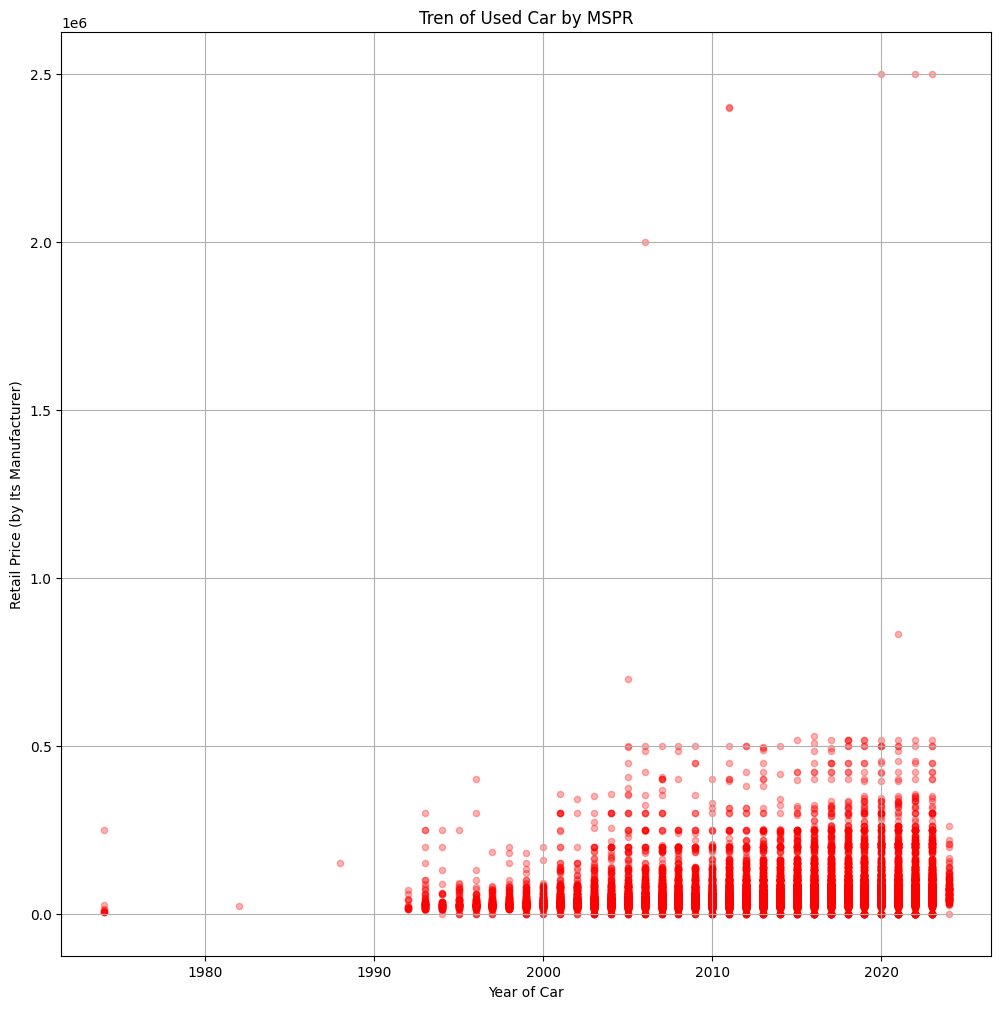

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,12))
plt.scatter(df['model_year'], df['msrp'], alpha=0.3, color='red', s=20)

plt.title('Tren of Used Car by MSPR')
plt.xlabel('Year of Car')
plt.ylabel('Retail Price (by Its Manufacturer)')
plt.grid(True)
plt.show()

In [102]:
from sklearn.linear_model import LinearRegression
import numpy as np

# df_clean = df[df["msrp"] < 1000000]
df_encoded = pd.get_dummies(df, columns=['brand', 'model', 'type'])

# Logika otomatis: membuang semua kolom hasil encoding brand, model, dan type
X = df_encoded.drop(['msrp'], axis = 1)
y = df_encoded['msrp'].values.reshape(-1, 1)

model = LinearRegression()
model.fit(X, y)

# X_line_predict = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
# y_line_predict = model.predict(X_line_predict)

# plt.figure(figsize=(12,12))
# plt.scatter(X, y, alpha=0.3, color='red', s=20, label='Data Asli')
# plt.plot(X_line_predict, y_line_predict, color='blue', linewidth=3, label='AI Prediction')

# plt.title('AI Predict - Used Car Price by Its Model')
# plt.xlabel('Year of Car')
# plt.ylabel('Retail Price (by Its Manufacturer)')
# plt.legend()
# plt.grid(True)
# plt.show()

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [103]:
from sklearn.metrics import mean_absolute_error, r2_score

y_predict_total = model.predict(X)

mae = mean_absolute_error(y, y_predict_total)
r2 = r2_score(y, y_predict_total)

print("=== REPORT OF YOUR NEWEST MODEL AI (BEFORE SPLIT)===")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"R-squared Score (R2): {r2:.4f}")

=== REPORT OF YOUR NEWEST MODEL AI (BEFORE SPLIT)===
Mean Absolute Error (MAE): $6246.01
R-squared Score (R2): 0.9441


In [104]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelAI = LinearRegression()
modelAI.fit(X_train, y_train)

y_resultofPrediction = modelAI.predict(X_test)
MAE = mean_absolute_error(y_test, y_resultofPrediction)
R2 = r2_score(y_test, y_resultofPrediction)

print("=== REPORT OF YOUR NEWEST MODEL AI (AFTER SPLIT)===")
print(f"MAE's Score: ${MAE:.2f}")
print(f"R-squared Score (R2): {R2:.4f}")

=== REPORT OF YOUR NEWEST MODEL AI (AFTER SPLIT)===
MAE's Score: $7267.30
R-squared Score (R2): 0.8660


In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

AImodel = KNeighborsRegressor(n_neighbors=5)

AImodel.fit(X_train, y_train)

test_predict = AImodel.predict(X_test)
MAE = mean_absolute_error(y_test, test_predict)
R2 = r2_score(y_test, test_predict)

print("=== REPORT OF YOUR NEWEST MODEL AI (KNN REGRESSOR)===")
print(f"MAE's Score: ${MAE:.2f}")
print(f"R-squared Score (R2): {R2:.4f}")

=== REPORT OF YOUR NEWEST MODEL AI (KNN REGRESSOR)===
MAE's Score: $26146.37
R-squared Score (R2): 0.1489


In [ ]:
import pandas as pd

mobil_baru = pd.DataFrame([{
    'model_year': 2020,
    'brand': 'Audi',
    'model': 'A7 3.0T Prestige',
    'type': 'Sedan',
    'miles_per_gallon': 22,
    'premium_version': 1,
    'collection_car': 0
}])

# 2. Aturan Pengawas (Transformer): Samakan format kolom dummy-nya dengan data latihan
mobil_baru_encoded = pd.get_dummies(mobil_baru)
mobil_baru_encoded = mobil_baru_encoded.reindex(columns=X.columns, fill_value=0)

# 3. tebak
harga_tebakan = modelAI.predict(mobil_baru_encoded)

print(f"Hasil Tebakan Harga AI Jujurmu: ${harga_tebakan[0][0]:.2f}")

Hasil Tebakan Harga AI Jujurmu: $78226.74


Mantap!